# Probability Foundations — Part 2
## Chapter 3: Expectations

This notebook develops the main ideas of expectation as a self-contained set of structured notes. It combines mathematical definitions, derivations, examples, and computational experiments.

The emphasis is on concepts that will remain useful in later probability, statistics, machine learning, and deep learning, while keeping advanced side topics concise.

## Notebook structure

The material progresses in the following order:

1. expected value for discrete and continuous random variables;
2. expectations of functions and basic algebraic properties;
3. variance, covariance, and correlation;
4. moments and generating functions;
5. conditional expectation and conditional variance;
6. a general formulation of expectation;
7. computational connections to sample averages and machine learning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# 1. Expected value

A probability distribution tells us which values a random variable can take and how likely they are, but we often need a **single representative quantity** that summarizes its overall location. Expectation serves this role: it forms a probability-weighted average of the possible values.

Expectation is one of the central operators in probability. Once it is defined, many other quantities—such as moments, variance, expected loss, and conditional averages—can be built from it.

For a **discrete** random variable \(X\) with support \(\mathcal{X}\),

$$
\boxed{
E[X]
=
\sum_{x\in\mathcal{X}} xP(X=x)
}
$$

The values \(x\) in the sum are the fixed possible values that \(X\) can take. The random object is \(X\); the index used to enumerate its possible values is not itself random.

For example, if

$$
Y\sim\operatorname{Binomial}(n,\theta),
$$

then the possible values of \(Y\) are

$$
0,1,\ldots,n.
$$

Therefore,

$$
E[Y]
=
\sum_{k=0}^{n} kP(Y=k)
=
0P(Y=0)+1P(Y=1)+\cdots+nP(Y=n).
$$

Here \(k\) is simply a **dummy summation index** ranging over the support of the binomial random variable.

## 1.1 Discrete example

Let \(X\) have pmf

$$
P(X=x)=
\begin{cases}
0.2,&x=0,\\
0.5,&x=1,\\
0.3,&x=3.
\end{cases}
$$

Then

$$
E[X]
=
0(0.2)+1(0.5)+3(0.3)
=
1.4.
$$

We can also compute

$$
E[X^2]
=
0^2(0.2)+1^2(0.5)+3^2(0.3)
=
3.2.
$$

The quantity \(E[X^2]\) will become useful when variance is introduced later.

In [2]:
x = np.array([0.0, 1.0, 3.0])
p = np.array([0.2, 0.5, 0.3])

EX = np.sum(x * p)
EX2 = np.sum(x**2 * p)

print("E[X] =", EX)
print("E[X^2] =", EX2)

E[X] = 1.4
E[X^2] = 3.1999999999999997


For an **absolutely continuous** random variable with density \(f_X\),

$$
\boxed{
E[X]
=
\int_{-\infty}^{\infty}x f_X(x)\,dx
}
$$

The sum in the discrete case and the integral in the continuous case play the same role: both average possible values using their probability weights.

## 1.2 Continuous example

Suppose

$$
f_X(x)=
\begin{cases}
2x,&0\le x\le1,\\
0,&\text{otherwise}.
\end{cases}
$$

Then

$$
E[X]
=
\int_0^1 x(2x)\,dx
=
\frac23.
$$

Similarly,

$$
E[X^2]
=
\int_0^1 x^2(2x)\,dx
=
\frac12.
$$

## 1.3 Some standard expectations

Several common distributions have expectations that are useful to recognize:

$$
X\sim U[L,R]
\quad\Longrightarrow\quad
E[X]=\frac{L+R}{2},
$$

$$
X\sim\operatorname{Exponential}(\lambda)
\quad\Longrightarrow\quad
E[X]=\frac1\lambda,
$$

and

$$
Z\sim N(0,1)
\quad\Longrightarrow\quad
E[Z]=0.
$$

For the standard normal distribution, the density is symmetric around zero, so the positive and negative contributions to the expectation cancel.

## 1.4 Count-distribution refresher

For count-valued models, it is useful to keep four related distributions distinct:

| Distribution | Trials | Categories per trial | Random quantity |
| --- | ---: | ---: | --- |
| Bernoulli | 1 | 2 | one binary outcome |
| Binomial | \(n\) | 2 | number of successes |
| Categorical | 1 | \(K\) | one category |
| Multinomial | \(n\) | \(K\) | count in each category |

For

$$
(X_1,\ldots,X_K)
\sim
\operatorname{Multinomial}(n;p_1,\ldots,p_K),
$$

the counts satisfy

$$
X_1+\cdots+X_K=n
$$

and each component has mean

$$
E[X_j]=np_j.
$$

# 2. Expectation of a function

Knowing \(E[X]\) alone is often not enough. In applications, the quantity of interest may be a transformation of the random variable—for example \(X^2\), a payoff function, an activation function, or a loss.

The purpose of this topic is to answer:

> If we know the distribution of \(X\), how can we compute the average value of \(g(X)\) without first deriving a new distribution for \(g(X)\)?

If \(g\) is a function, then for discrete \(X\),

$$
\boxed{
E[g(X)]
=
\sum_x g(x)P(X=x)
}
$$

and for absolutely continuous \(X\),

$$
\boxed{
E[g(X)]
=
\int g(x)f_X(x)\,dx.
}
$$

This result is commonly called the **Law of the Unconscious Statistician (LOTUS)**.

Its practical value is that we can compute \(E[g(X)]\) directly from the distribution of \(X\), without first deriving the full distribution of \(g(X)\).

## 2.1 Example

Let

$$
X\sim U(0,1),
\qquad
Y=X^2.
$$

Then

$$
E[Y]
=
E[X^2]
=
\int_0^1x^2\,dx
=
\frac13.
$$

## 2.2 Computer experiment

Take

$$
X\sim N(0,1)
$$

and consider the transformation

$$
g(X)=X^2.
$$

Because the standard normal has mean \(0\) and variance \(1\),

$$
E[X^2]=1.
$$

In [3]:
x_normal = rng.normal(0, 1, size=100_000)

print("Estimated E[X^2] =", np.mean(x_normal**2))
print("Theoretical E[X^2] = 1")

Estimated E[X^2] = 1.007438237317312
Theoretical E[X^2] = 1


Another transformation that appears frequently in deep learning is

$$
\operatorname{ReLU}(x)=\max(0,x).
$$

The same principle allows us to study quantities such as

$$
E[\operatorname{ReLU}(X)].
$$

In [4]:
relu_x = np.maximum(0, x_normal)

print("Estimated E[ReLU(X)] =", relu_x.mean())

Estimated E[ReLU(X)] = 0.39757811275697413


# 3. Basic properties of expectation

Once expectation is defined, we need rules for manipulating it efficiently. These properties let us simplify expectations of combined or transformed random variables without repeatedly returning to the full sum or integral definition.

Expectation is **linear**. For constants \(a,b,c\),

$$
\boxed{
E[aX+bY+c]
=
aE[X]+bE[Y]+c.
}
$$

No independence assumption is needed.

Expectation is also **monotone**:

$$
X\le Y
\quad\Longrightarrow\quad
E[X]\le E[Y].
$$

A different property applies to products. If \(X\) and \(Y\) are independent, then

$$
\boxed{
E[XY]=E[X]E[Y].
}
$$

Thus independence is unnecessary for linearity of sums, but it is a sufficient condition for factorizing the expectation of a product.

## 3.1 Example

Suppose

$$
E[X]=3,
\qquad
E[Y]=-1.
$$

Then

$$
E[4X-2Y+5]
=
4E[X]-2E[Y]+5
=
19.
$$

# 4. Expected value and the St. Petersburg paradox

Expectation is mathematically precise, but its interpretation must still be handled carefully. The **St. Petersburg paradox** is a useful example because it shows that a mathematically large—or even infinite—expected monetary payoff does not automatically translate into an equally large practical value.

Consider the following game:

1. Flip a fair coin until the first head appears.
2. If the first head appears on toss \(k\), the payoff is

$$
X=2^k.
$$

The probability that the first head occurs on toss \(k\) is

$$
P(X=2^k)
=
\left(\frac12\right)^k.
$$

Therefore,

$$
E[X]
=
\sum_{k=1}^{\infty}
2^k
\left(\frac12\right)^k.
$$

But every term is

$$
2^k\left(\frac12\right)^k=1,
$$

so

$$
E[X]
=
\sum_{k=1}^{\infty}1
=
\infty.
$$

The important mechanism is not that one individual outcome has an infinite payoff. Every possible payoff \(2^k\) is finite. The divergence occurs because, as \(k\) increases,

- the probability decreases like \(2^{-k}\);
- the payoff increases like \(2^k\);

and these two effects cancel exactly:

$$
2^k\cdot 2^{-k}=1.
$$

Thus even extremely unlikely events continue to contribute the same amount to the expectation, and infinitely many such contributions make the total diverge.

## 4.1 What happens if the payoff is capped?

Now suppose the casino imposes a maximum payoff

$$
M=2^{20}=1{,}048{,}576.
$$

The capped payoff is

$$
X_{\text{cap}}
=
\min(X,2^{20}).
$$

For \(k=1,\ldots,19\), the payoff is still \(2^k\), so each of those levels contributes

$$
2^k\left(\frac12\right)^k=1.
$$

If the first head does not appear before toss 20, the payoff is capped at \(2^{20}\). The probability of reaching toss 20 or later is

$$
P(K\ge20)
=
\left(\frac12\right)^{19}.
$$

Hence the capped tail contributes

$$
2^{20}\left(\frac12\right)^{19}
=
2.
$$

Therefore,

$$
E[X_{\text{cap}}]
=
19+2
=
21.
$$

So a maximum possible payoff of more than one million dollars still produces an expected payoff of only

$$
\$21.
$$

This is the key contrast:

- with no upper bound, infinitely many payoff levels each contribute about the same amount, so the expectation diverges;
- with a finite cap, only finitely much total contribution remains, so the expectation becomes finite.

The example shows that

$$
E[X]
$$

describes a mathematical average payoff, but it is not automatically identical to subjective value or a rational entry price. One possible extension is to evaluate a utility function,

$$
E[U(X)],
$$

rather than money directly.

# 5. Variance and standard deviation

Two random variables can have the same expectation while behaving very differently. One may stay close to its mean, while another may frequently take values far away from it.

Variance was introduced to quantify this **spread around the mean**. Standard deviation expresses the same spread on the original scale of the variable.

Let

$$
\mu_X=E[X].
$$

The variance of \(X\) is

$$
\boxed{
\operatorname{Var}(X)
=
E[(X-\mu_X)^2].
}
$$

For a discrete random variable,

$$
\operatorname{Var}(X)
=
\sum_x (x-\mu_X)^2P(X=x),
$$

while for an absolutely continuous random variable,

$$
\operatorname{Var}(X)
=
\int (x-\mu_X)^2f_X(x)\,dx.
$$

Expanding the square gives the useful identity

$$
\boxed{
\operatorname{Var}(X)
=
E[X^2]-(E[X])^2.
}
$$

The standard deviation is

$$
\boxed{
\operatorname{Sd}(X)
=
\sqrt{\operatorname{Var}(X)}.
}
$$

## 5.1 Reusing the earlier discrete example

Earlier we found

$$
E[X]=1.4,
\qquad
E[X^2]=3.2.
$$

Therefore,

$$
\operatorname{Var}(X)
=
3.2-(1.4)^2
=
1.24.
$$

## 5.2 Affine transformations

If

$$
Y=aX+b,
$$

then

$$
E[Y]=aE[X]+b,
$$

but

$$
\boxed{
\operatorname{Var}(Y)
=
a^2\operatorname{Var}(X).
}
$$

Adding \(b\) shifts the distribution without changing its spread. Multiplying by \(a\) scales every deviation from the mean by \(a\), so the squared deviations scale by \(a^2\).

For example, if

$$
E[X]=4,
\qquad
\operatorname{Var}(X)=9,
$$

and

$$
Y=3X+7,
$$

then

$$
E[Y]=19,
\qquad
\operatorname{Var}(Y)=81.
$$

# 6. Covariance

Variance tells us how one random variable varies by itself. When two random variables are observed together, we also want to know whether their deviations from their means tend to occur in the same direction or in opposite directions.

Covariance was introduced to quantify this **joint linear co-variation**.

For random variables \(X\) and \(Y\),

$$
\boxed{
\operatorname{Cov}(X,Y)
=
E[(X-\mu_X)(Y-\mu_Y)].
}
$$

For discrete \(X\) and \(Y\), this can be written as

$$
\operatorname{Cov}(X,Y)
=
\sum_{x,y}
(x-\mu_X)(y-\mu_Y)
P(X=x,Y=y).
$$

Expanding the product gives the computational identity

$$
\boxed{
\operatorname{Cov}(X,Y)
=
E[XY]-E[X]E[Y].
}
$$

If the two variables tend to deviate from their means in the same direction, covariance is positive. If they tend to move in opposite directions, covariance is negative.

## 6.1 Scaling examples

Let

$$
Y=3X,
\qquad
Z=-4X.
$$

Then

$$
\operatorname{Cov}(X,Y)
=
3\operatorname{Var}(X)>0,
$$

while

$$
\operatorname{Cov}(X,Z)
=
-4\operatorname{Var}(X)<0.
$$

## 6.2 Independence and covariance

If \(X\) and \(Y\) are independent, then

$$
E[XY]=E[X]E[Y],
$$

so

$$
\boxed{
X\perp Y
\quad\Longrightarrow\quad
\operatorname{Cov}(X,Y)=0.
}
$$

The converse is not true in general. Two random variables may have zero covariance while still being dependent. This limitation becomes even clearer after correlation is introduced.

# 7. Variance of sums

When random quantities are added together, their expectations add immediately by linearity. Their variances are more subtle because the variables may move together.

The purpose of this result is to determine **how the uncertainty of a sum depends both on the uncertainty of each term and on the relationships between the terms**.

For two random variables,

$$
\boxed{
\operatorname{Var}(X+Y)
=
\operatorname{Var}(X)
+
\operatorname{Var}(Y)
+
2\operatorname{Cov}(X,Y).
}
$$

More generally,

$$
\boxed{
\operatorname{Var}\left(\sum_{i=1}^{n}X_i\right)
=
\sum_{i=1}^{n}\operatorname{Var}(X_i)
+
2\sum_{i<j}\operatorname{Cov}(X_i,X_j).
}
$$

## 7.1 Derivation of the general form

Let

$$
A_i=X_i-\mu_i,
\qquad
\mu_i=E[X_i].
$$

Then

$$
\operatorname{Var}\left(\sum_i X_i\right)
=
E\left[
\left(\sum_i A_i\right)^2
\right].
$$

A square is a product of two copies of the same sum:

$$
\left(\sum_i A_i\right)^2
=
\left(\sum_i A_i\right)
\left(\sum_j A_j\right).
$$

The second copy uses the dummy index \(j\) so that the two indices can vary independently. Expanding gives every ordered pair:

$$
\sum_{i,j}A_iA_j.
$$

For three variables, the terms can be arranged as

$$
\begin{array}{c|ccc}
 & j=1 & j=2 & j=3\\
\hline
i=1&A_1A_1&A_1A_2&A_1A_3\\
i=2&A_2A_1&A_2A_2&A_2A_3\\
i=3&A_3A_1&A_3A_2&A_3A_3
\end{array}
$$

The diagonal terms \(i=j\) are

$$
A_i^2,
$$

and after taking expectations they become variances.

The off-diagonal terms occur in symmetric pairs:

$$
A_iA_j
\quad\text{and}\quad
A_jA_i.
$$

Because multiplication is commutative, each pair contributes the same value twice. Hence,

$$
\sum_{i,j}E[A_iA_j]
=
\sum_iE[A_i^2]
+
2\sum_{i<j}E[A_iA_j].
$$

Recognizing the variance and covariance terms gives the general formula.

If \(X_1,\ldots,X_n\) are independent, every pairwise covariance is zero. Therefore,

$$
\boxed{
\operatorname{Var}\left(\sum_{i=1}^{n}X_i\right)
=
\sum_{i=1}^{n}\operatorname{Var}(X_i).
}
$$

This result will be especially important when studying sums and averages of independent samples.

# 8. Correlation

Covariance tells us the direction of linear co-variation, but its numerical magnitude depends on the units and scales of the variables. This makes covariance values difficult to compare across different pairs of variables.

Correlation solves this problem by **standardizing covariance**, producing a unit-free measure of linear association.

$$
\boxed{
\operatorname{Corr}(X,Y)
=
\frac{\operatorname{Cov}(X,Y)}
{\operatorname{Sd}(X)\operatorname{Sd}(Y)}.
}
$$

Provided the variances are finite and nonzero,

$$
-1\le \operatorname{Corr}(X,Y)\le1.
$$

For the earlier examples,

$$
Y=3X
\quad\Longrightarrow\quad
\operatorname{Corr}(X,Y)=1,
$$

and

$$
Z=-4X
\quad\Longrightarrow\quad
\operatorname{Corr}(X,Z)=-1.
$$

The scale factors cancel, so correlation measures the direction and strength of **linear association** on a standardized scale.

## 8.1 Nonlinear dependence can have zero correlation

Let

$$
X\sim U(-1,1),
\qquad
Y=X^2.
$$

The variable \(Y\) is completely determined by \(X\), so \(X\) and \(Y\) are dependent.

However, symmetry gives

$$
E[X]=0,
\qquad
E[XY]
=
E[X^3]
=
0.
$$

Therefore,

$$
\operatorname{Cov}(X,Y)=0
$$

and hence the correlation is also zero.

This example shows why zero correlation should not be interpreted as general independence.

In [5]:
x_uniform = rng.uniform(-1, 1, size=100_000)
y_curve = x_uniform**2

covariance = np.cov(x_uniform, y_curve, ddof=0)[0, 1]
correlation = np.corrcoef(x_uniform, y_curve)[0, 1]

print("Estimated covariance:", covariance)
print("Estimated correlation:", correlation)

Estimated covariance: 0.00032753012611784016
Estimated correlation: 0.0019034576166547322


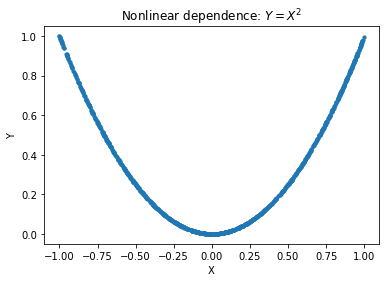

In [6]:
plt.figure()
plt.scatter(x_uniform[:1000], y_curve[:1000], s=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(r"Nonlinear dependence: $Y=X^2$")
plt.show()

## 8.2 Bivariate normal examples

For a bivariate normal distribution, the correlation parameter \(\rho\) directly controls the linear orientation of the joint point cloud.

The following simulations compare

$$
\rho\in\{0,0.5,0.9,-0.9\}.
$$

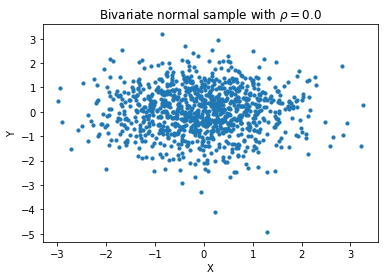

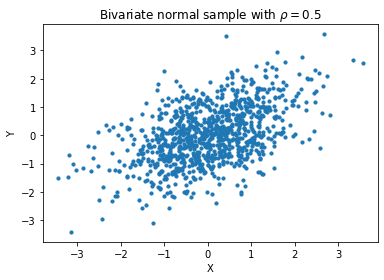

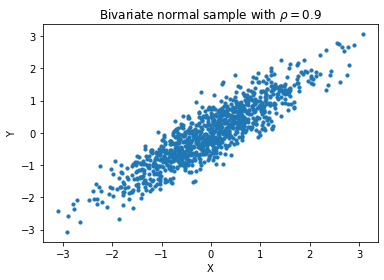

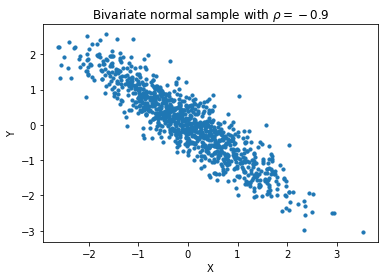

In [7]:
rho_values = [0.0, 0.5, 0.9, -0.9]

for rho in rho_values:
    covariance_matrix = np.array([[1.0, rho], [rho, 1.0]])
    samples = rng.multivariate_normal(
        mean=[0.0, 0.0],
        cov=covariance_matrix,
        size=1000,
    )

    plt.figure()
    plt.scatter(samples[:, 0], samples[:, 1], s=10)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(fr"Bivariate normal sample with $\rho={rho}$")
    plt.show()

# 9. Moments and generating functions

A probability distribution contains more information than its mean and variance. **Moments** provide a systematic family of numerical summaries, while **generating functions** encode distributional information in a form that can be differentiated, multiplied, and otherwise manipulated algebraically.

The main idea is to replace a probability distribution by a function that stores useful information about that distribution. Different generating functions are designed for different settings.

The \(k\)th **raw moment** of \(X\) is

$$
\boxed{
E[X^k].
}
$$

The first raw moment is the mean:

$$
E[X].
$$

The second raw moment helps determine the variance:

$$
\operatorname{Var}(X)
=
E[X^2]-(E[X])^2.
$$

A related quantity is the \(k\)th **central moment**,

$$
E[(X-E[X])^k],
$$

and variance is the second central moment.

Moments therefore summarize increasingly high-order features of a distribution. Generating functions provide a compact way to store or recover these moments—and, in some cases, the full probability distribution.

## 9.1 Probability-generating function

For a nonnegative integer-valued random variable,

$$
\boxed{
G_X(t)=E[t^X].
}
$$

Using the pmf,

$$
G_X(t)
=
\sum_{k=0}^{\infty} t^kP(X=k).
$$

This power series stores the probabilities directly as its coefficients:

$$
G_X(t)
=
P(X=0)
+
P(X=1)t
+
P(X=2)t^2
+\cdots.
$$

So for nonnegative integer-valued distributions, the PGF can be viewed as a **compact representation of the entire pmf**. The probabilities can be recovered through derivatives:

$$
\boxed{
P(X=k)
=
\frac{G_X^{(k)}(0)}{k!}.
}
$$

The PGF can also generate useful moments. For example,

$$
G_X'(1)=E[X],
$$

and

$$
G_X''(1)=E[X(X-1)].
$$

Thus a PGF is useful both as an encoding of the probability mass function and as a tool for extracting numerical summaries.

For independent nonnegative integer-valued random variables,

$$
\boxed{
G_{X+Y}(t)
=
G_X(t)G_Y(t).
}
$$

This product rule makes PGFs particularly useful for sums of independent count variables.

## 9.2 Moment-generating function

The **moment-generating function (MGF)** is

$$
\boxed{
M_X(s)=E[e^{sX}].
}
$$

Its main purpose is to package the raw moments of a distribution into one function.

Using the power-series expansion

$$
e^{sX}
=
1+sX+\frac{s^2X^2}{2!}
+\frac{s^3X^3}{3!}+\cdots,
$$

we obtain, formally,

$$
M_X(s)
=
1+sE[X]
+\frac{s^2}{2!}E[X^2]
+\frac{s^3}{3!}E[X^3]
+\cdots.
$$

Therefore, whenever the MGF exists in a neighborhood of zero,

$$
\boxed{
M_X^{(k)}(0)
=
E[X^k].
}
$$

So a single MGF can generate

$$
E[X],\quad
E[X^2],\quad
E[X^3],\ldots
$$

through repeated differentiation.

This does **not** mean that the MGF directly generates every possible expectation \(E[g(X)]\). Its special role is that it generates the sequence of raw moments \(E[X^k]\), and in many common cases the MGF also uniquely identifies the distribution.

For independent random variables,

$$
\boxed{
M_{X+Y}(s)
=
M_X(s)M_Y(s).
}
$$

This is another major reason MGFs are useful: the distribution of a sum can often be studied by multiplying the MGFs of its independent components.

The PGF and MGF are related for nonnegative integer-valued \(X\):

$$
M_X(s)
=
G_X(e^s),
$$

whenever the relevant functions are defined.

For independent random variables,

$$
\boxed{
M_{X+Y}(s)
=
M_X(s)M_Y(s).
}
$$

This is one reason transforms are useful: addition of independent random variables becomes multiplication of functions.

## 9.3 Characteristic functions

The MGF has an important limitation: for some distributions,

$$
E[e^{sX}]
$$

becomes infinite for nonzero values of \(s\), so the MGF does not exist in a usable neighborhood around zero.

The **characteristic function** solves this problem by replacing the real exponential \(e^{sX}\) with the complex exponential

$$
e^{isX},
$$

where \(i^2=-1\):

$$
\boxed{
\phi_X(s)
=
E[e^{isX}].
}
$$

The crucial difference is

$$
|e^{isX}|=1.
$$

Because the magnitude never grows with \(X\), the expectation cannot diverge for the same reason an MGF can. As a result, the characteristic function exists for **every probability distribution**.

Like MGFs, characteristic functions also transform sums of independent random variables into products:

$$
\boxed{
\phi_{X+Y}(s)
=
\phi_X(s)\phi_Y(s).
}
$$

They therefore preserve many of the useful algebraic features of MGFs while avoiding the MGF's finiteness problem. This is why characteristic functions become especially important in advanced probability and convergence theory.

# 10. Conditional expectation

An ordinary expectation summarizes a random variable using all currently available uncertainty. But once additional information is observed, the relevant probabilities may change, and the appropriate average should change with them.

Conditional expectation provides this **updated average after conditioning on information**. It is one of the main tools for reasoning about prediction and dependence.

Conditioning changes the probability distribution being used. Conditional expectation therefore applies the usual expectation operation to a conditional distribution.

## 10.1 Conditioning on an event

For a discrete random variable \(X\) and an event \(A\) with \(P(A)>0\),

$$
\boxed{
E[X\mid A]
=
\sum_x xP(X=x\mid A).
}
$$

The form is exactly the same as ordinary expectation; only the probability weights have changed from \(P(X=x)\) to \(P(X=x\mid A)\).

## 10.2 Conditioning on a discrete random variable

For discrete random variables \(X\) and \(Y\), fixing \(Y=y\) gives

$$
\boxed{
E[X\mid Y=y]
=
\sum_x xP(X=x\mid Y=y).
}
$$

For a fixed \(y\), this is an ordinary number.

Now define

$$
g(y)=E[X\mid Y=y].
$$

If the value of \(Y\) has not yet been observed, then

$$
\boxed{
E[X\mid Y]=g(Y).
}
$$

Because \(Y\) is random, \(E[X\mid Y]\) is itself a random variable.

## 10.3 Continuous case

If \(X\) and \(Y\) are jointly absolutely continuous, the conditional density is

$$
f_{X\mid Y}(x\mid y)
=
\frac{f_{X,Y}(x,y)}{f_Y(y)}
$$

for values of \(y\) where \(f_Y(y)>0\).

Then

$$
\boxed{
E[X\mid Y=y]
=
\int x f_{X\mid Y}(x\mid y)\,dx.
}
$$

So the same principle holds in both settings:

- ordinary expectation uses the marginal distribution of \(X\);
- conditional expectation uses the distribution of \(X\) after conditioning on \(Y=y\).

## 10.4 Law of total expectation

A fundamental identity is

$$
\boxed{
E[E[X\mid Y]]
=
E[X].
}
$$

For discrete \(Y\),

$$
E[E[X\mid Y]]
=
\sum_y E[X\mid Y=y]P(Y=y).
$$

This is a weighted average of the conditional means. Averaging across all possible values of \(Y\) recovers the overall mean of \(X\).

### Computer experiment

Suppose

$$
P(Y=0)=P(Y=1)=\frac12,
$$

with

$$
X\mid Y=0\sim\operatorname{Bernoulli}(0.2),
$$

and

$$
X\mid Y=1\sim\operatorname{Bernoulli}(0.8).
$$

Then

$$
E[X\mid Y]
=
\begin{cases}
0.2,&Y=0,\\
0.8,&Y=1,
\end{cases}
$$

and

$$
E[X]=0.5.
$$

In [8]:
n = 200_000
y = rng.binomial(1, 0.5, size=n)

conditional_success_probability = np.where(y == 0, 0.2, 0.8)
x_conditional = rng.binomial(1, conditional_success_probability)

conditional_mean = np.where(y == 0, 0.2, 0.8)

print("Empirical E[X]        =", x_conditional.mean())
print("Empirical E[E[X|Y]]   =", conditional_mean.mean())
print("Theoretical value     = 0.5")

Empirical E[X]        = 0.50042
Empirical E[E[X|Y]]   = 0.4994839999999999
Theoretical value     = 0.5


# 11. Conditional variance

Conditional expectation describes the center of a random variable after information is observed, but it does not describe how much uncertainty remains.

Conditional variance measures this **remaining spread after conditioning**.

It is defined by

$$
\boxed{
\operatorname{Var}(X\mid Y)
=
E\left[
\left(
X-E[X\mid Y]
\right)^2
\middle|Y
\right].
}
$$

As with ordinary variance,

$$
\boxed{
\operatorname{Var}(X\mid Y)
=
E[X^2\mid Y]
-
(E[X\mid Y])^2.
}
$$

## 11.1 Law of total variance

The total variance of \(X\) can be decomposed as

$$
\boxed{
\operatorname{Var}(X)
=
\operatorname{Var}(E[X\mid Y])
+
E[\operatorname{Var}(X\mid Y)].
}
$$

The two terms have a useful interpretation:

$$
\text{total variation}
=
\text{variation of conditional means}
+
\text{average variation remaining within conditions}.
$$

### Computer experiment

Construct

$$
X=3Y+\varepsilon,
$$

where

$$
Y\sim\operatorname{Bernoulli}(0.4)
$$

and

$$
\varepsilon\sim N(0,1)
$$

independently.

Then

$$
E[X\mid Y]=3Y
$$

and

$$
\operatorname{Var}(X\mid Y)=1.
$$

In [9]:
n = 300_000
y_tv = rng.binomial(1, 0.4, size=n)
eps = rng.normal(0, 1, size=n)
x_tv = 3 * y_tv + eps

conditional_mean_tv = 3 * y_tv
conditional_variance_tv = np.ones(n)

lhs = np.var(x_tv)
rhs = np.var(conditional_mean_tv) + np.mean(conditional_variance_tv)

print("Var(X) =", lhs)
print("Var(E[X|Y]) + E[Var(X|Y)] =", rhs)

Var(X) = 3.1620917794640198
Var(E[X|Y]) + E[Var(X|Y)] = 3.1618088190999987


# 12. General expectation

The discrete sum and continuous density integral are convenient formulas, but not every probability distribution is purely discrete or purely absolutely continuous. A distribution may contain both types of behavior.

A general formulation is therefore needed so that **expectation remains one unified concept rather than two unrelated definitions**.

A useful tail-integral representation is

$$
E[X]
=
\int_0^\infty P(X>t)\,dt
-
\int_{-\infty}^{0}P(X<t)\,dt,
$$

under suitable existence conditions.

For a nonnegative random variable, this simplifies to

$$
\boxed{
E[X]
=
\int_0^\infty P(X>t)\,dt.
}
$$

This representation shows that expectation can also be understood as the area under the tail-probability curve.

## 12.1 Exponential example

If

$$
X\sim\operatorname{Exponential}(\lambda),
$$

then

$$
P(X>t)=e^{-\lambda t},
\qquad t\ge0.
$$

Therefore,

$$
E[X]
=
\int_0^\infty e^{-\lambda t}\,dt
=
\frac1\lambda.
$$

In [10]:
lam = 2.0
t = np.linspace(0, 10, 200_000)
tail = np.exp(-lam * t)

dt = np.diff(t)
tail_integral = np.sum(
    0.5 * (tail[:-1] + tail[1:]) * dt
)

print("Numerical tail integral =", tail_integral)
print("Theoretical E[X] =", 1 / lam)

Numerical tail integral = 0.4999999993860941
Theoretical E[X] = 0.5


# 13. Expectation and sample averages

Expectation is defined from a probability distribution, but in real data problems the underlying distribution is usually unknown. What we actually observe is a finite sample.

The sample average is therefore important because it provides a **data-based approximation to a theoretical expectation**.

Let

$$
X\sim\operatorname{Bernoulli}(0.3).
$$

Then

$$
E[X]=0.3.
$$

For independent observations \(X_1,\ldots,X_n\), the sample mean is

$$
\bar X_n
=
\frac1n\sum_{i=1}^{n}X_i.
$$

The following experiment shows how the sample mean behaves as the sample size grows.

In [11]:
p = 0.3

for n in [10, 100, 1_000, 10_000, 100_000]:
    samples = rng.binomial(1, p, size=n)
    print(f"n={n:>6}: sample mean = {samples.mean():.5f}")

n=    10: sample mean = 0.30000
n=   100: sample mean = 0.31000
n=  1000: sample mean = 0.29500
n= 10000: sample mean = 0.30030
n=100000: sample mean = 0.30009


As \(n\) grows, the empirical average tends to stabilize near the theoretical mean.

The **Law of Large Numbers** will make this relationship precise when sampling distributions and limits are studied.

# 14. Two direct machine-learning connections

Expectation enters machine learning most directly when an ideal objective is defined over an unknown data-generating distribution but must be approximated using observed samples.

A second important connection is prediction: conditional expectation identifies the best predictor under squared-error loss.

These two ideas provide a direct bridge from the probability concepts developed in this chapter to later learning algorithms.

## 14.1 Expected loss and empirical risk

Suppose a model \(f_\theta\) predicts a target \(Y\) from an input \(X\), and consider squared-error loss:

$$
L(\theta;X,Y)
=
(Y-f_\theta(X))^2.
$$

The population objective is the expected loss,

$$
\boxed{
R(\theta)
=
E[(Y-f_\theta(X))^2].
}
$$

The true data distribution is usually unknown, so with observations

$$
(x_1,y_1),\ldots,(x_n,y_n),
$$

we use the empirical average

$$
\boxed{
\hat R_n(\theta)
=
\frac1n
\sum_{i=1}^{n}
(y_i-f_\theta(x_i))^2.
}
$$

This is the basic connection between expectation and empirical risk minimization.

In [12]:
def model(x, theta):
    return theta * x

theta = 2.0

x_population = rng.normal(0, 1, size=500_000)
noise_population = rng.normal(0, 0.5, size=500_000)
y_population = 2.5 * x_population + noise_population

population_risk_approx = np.mean(
    (y_population - model(x_population, theta))**2
)

n = 100
x_sample = rng.normal(0, 1, size=n)
noise_sample = rng.normal(0, 0.5, size=n)
y_sample = 2.5 * x_sample + noise_sample

empirical_risk = np.mean(
    (y_sample - model(x_sample, theta))**2
)

print("Large-sample approximation to population risk:", population_risk_approx)
print("Empirical risk from n=100:", empirical_risk)

Large-sample approximation to population risk: 0.5004755782837672
Empirical risk from n=100: 0.4771617216149988


## 14.2 Conditional expectation as an MSE-optimal predictor

Suppose we want to predict \(X\) using only information contained in \(Y\).

Among all functions \(g(Y)\), the function minimizing

$$
E[(X-g(Y))^2]
$$

is

$$
\boxed{
g^*(Y)=E[X\mid Y].
}
$$

Thus conditional expectation is not only a probability-theory construction; it is also the optimal predictor under squared-error loss.

### Numerical illustration

Suppose

$$
X=2Y+\varepsilon,
$$

where \(\varepsilon\) is independent of \(Y\) and has mean zero.

Then

$$
E[X\mid Y]=2Y.
$$

Compare three predictors:

$$
g_1(Y)=0,
\qquad
g_2(Y)=1.5Y,
\qquad
g_3(Y)=2Y.
$$

In [13]:
n = 200_000
y_pred = rng.normal(0, 1, size=n)
eps_pred = rng.normal(0, 0.7, size=n)
x_target = 2 * y_pred + eps_pred

predictions = {
    "g(Y)=0": np.zeros_like(y_pred),
    "g(Y)=1.5Y": 1.5 * y_pred,
    "g(Y)=2Y = E[X|Y]": 2.0 * y_pred,
}

for name, pred in predictions.items():
    mse = np.mean((x_target - pred)**2)
    print(f"{name:18s}  MSE = {mse:.5f}")

g(Y)=0              MSE = 4.48876
g(Y)=1.5Y           MSE = 0.74092
g(Y)=2Y = E[X|Y]    MSE = 0.48910


The conditional-mean predictor achieves the smallest mean-squared error among these candidates.

# 15. Core formulas

### Expectation

$$
E[X]
$$

### Expectation of a function

$$
E[g(X)]
$$

### Linearity

$$
E[aX+bY+c]
=
aE[X]+bE[Y]+c
$$

### Variance

$$
\operatorname{Var}(X)
=
E[X^2]-(E[X])^2
$$

### Covariance

$$
\operatorname{Cov}(X,Y)
=
E[XY]-E[X]E[Y]
$$

### Variance of a sum

$$
\operatorname{Var}\left(\sum_iX_i\right)
=
\sum_i\operatorname{Var}(X_i)
+
2\sum_{i<j}\operatorname{Cov}(X_i,X_j)
$$

### Correlation

$$
\operatorname{Corr}(X,Y)
=
\frac{\operatorname{Cov}(X,Y)}
{\operatorname{Sd}(X)\operatorname{Sd}(Y)}
$$

### MGF moments

$$
M_X^{(k)}(0)=E[X^k]
$$

when the required existence conditions hold.

### Total expectation

$$
E[E[X\mid Y]]=E[X]
$$

### Total variance

$$
\operatorname{Var}(X)
=
\operatorname{Var}(E[X\mid Y])
+
E[\operatorname{Var}(X\mid Y)]
$$

### Tail formula for \(X\ge0\)

$$
E[X]
=
\int_0^\infty P(X>t)\,dt.
$$

# 16. Main takeaways

1. Expectation is a probability-weighted average of the possible values of a random variable.
2. LOTUS lets us compute expectations of transformations directly from the original distribution.
3. Linearity of expectation does not require independence.
4. Variance measures spread around the mean; covariance measures joint linear co-variation.
5. Independence implies zero covariance, but zero covariance does not imply independence.
6. Correlation is standardized covariance and measures linear association rather than arbitrary dependence.
7. Covariance terms explain why variances of dependent sums do not simply add.
8. Moments and generating functions provide compact ways to encode information about distributions.
9. Conditional expectation is a random variable when conditioned on another random variable.
10. The laws of total expectation and total variance recover global quantities from conditional structure.
11. The usual discrete and continuous expectation formulas fit into a more general notion of expectation.

# 17. Connections to later topics

Several ideas from this chapter will reappear directly in later parts of the learning path.

### Sampling Distributions and Limits

For independent observations,

$$
E\left[\sum_i X_i\right]
=
\sum_iE[X_i]
$$

and

$$
\operatorname{Var}\left(\sum_iX_i\right)
=
\sum_i\operatorname{Var}(X_i).
$$

These results determine the expectation and variance of sample sums and sample means. They are central to the **Law of Large Numbers** and the **Central Limit Theorem**.

Generating functions and characteristic functions also provide tools for studying sums and convergence in distribution.

### Relationships among Variables

Covariance, correlation, and conditional expectation are major tools for describing how random variables are related.

They support later questions such as:

- how strongly two variables vary together;
- whether a relationship is linear or more general;
- how the expected value of one variable changes after another is observed.

### Bayesian Inference and Bayesian Statistics

Bayesian inference repeatedly conditions on observed information. Conditional distributions and conditional expectation therefore become fundamental.

Posterior expectations summarize quantities after data have been observed, and under squared-error loss the conditional mean has the interpretation of an optimal predictor.

### Likelihood Inference and Maximum Likelihood Estimation

For independent observations, log-likelihoods are sums over data points and are often normalized into sample averages.

This creates a direct structural connection between likelihood-based objectives and the expectation/sample-average viewpoint developed here.

### Information Theory

Several central quantities in information theory are expectations. For example, entropy can be written as

$$
H(X)
=
E[-\log p(X)]
$$

for a discrete random variable with pmf \(p\).

Thus expectations of functions become directly useful when studying entropy, cross-entropy, and related quantities.

### Learning Algorithms and Stochastic Gradient Descent

Machine-learning objectives are often population expectations,

$$
E[\ell(f_\theta(X),Y)],
$$

while training uses datasets and mini-batches to form sample-based estimates.

The relationship between expectation and sample averages is therefore central to **empirical risk minimization** and **stochastic gradient descent**.

### Parameter Initialization Strategies

In deep networks, activations and gradients are repeatedly formed from sums of many random terms.

Initialization methods therefore track quantities such as means and variances across layers. The expectation and variance rules developed here provide the probability foundation for understanding variance-preserving initialization.

# Reference

- *Probability and Statistics: The Science of Uncertainty*, Chapter 3: Expectation.